This script follows the capstone stage two black box optimisation challenge, this is the first attempt for week 1

In [7]:
from __future__ import print_function

import math
import os
import random
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import torch
import torch.nn as nn
import torch.nn.functional as func
from aima3 import learning
from mlxtend.plotting import plot_decision_regions
from numpy import random as np_random
from scipy.stats import norm
from sklearn import svm
from sklearn.decomposition import PCA
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, RBF, WhiteKernel
from sklearn.manifold import TSNE
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import KFold
from sklearn.preprocessing import MinMaxScaler, StandardScaler

%matplotlib inline

In [8]:

# Acquisition functions 
# UCB function 
def acquisition_UCB(beta, mean, stddev, candidates):

    ucb = mean + beta * stddev # compute UCB 
    best_index = np.argmax(ucb) # find the argument x of a(x) that maximises 

    # use index to find best candidate function

    

    return np.round(candidates[best_index],6)

def accquisition_expected_improvement(mu, sigma, f_best, xi=0.0):
    """
    Compute Expected Improvement.

    Parameters
    ----------
    mu : array
        Posterior mean
    sigma : array
        Posterior std
    f_best : float
        Best observed value so far
    xi : float
        Exploration parameter (small positive value)

    Returns
    -------
    EI : array
    """

    sigma = np.maximum(sigma, 1e-12)  # avoid division by zero

    improvement = mu - f_best - xi
    Z = improvement / sigma

    EI = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)

    EI[sigma < 1e-12] = 0.0

    return EI


def accquisition_prob_improve(mu, sigma, f_best, xi=0.01):
    """
    Probability of Improvement (PI) acquisition function.

    Parameters
    ----------
    mu : array-like
        Posterior mean from GP
    sigma : array-like
        Posterior standard deviation from GP
    f_best : float
        Best observed value so far
    xi : float
        Exploration parameter (encourages exploration)

    Returns
    -------
    PI : array
        Probability of improvement at each point
    """

    mu = np.asarray(mu)
    sigma = np.asarray(sigma)

    # avoid division by zero
    sigma = np.maximum(sigma, 1e-12)

    Z = (mu - f_best - xi) / sigma

    PI = norm.cdf(Z)

    # if sigma ~ 0 → no uncertainty → no improvement possible
    PI[sigma < 1e-12] = 0.0

    return PI



In [9]:
# Gaussian process surrogate models
# implement GPR with a RBF kernel 
def GPR_with_RBF_kernel_monte_carlo(rbf_lengthscale,
                        noise_assumption,
                        ins,outs,
                        sample_size,
                        in_cols):
    kernel = RBF(length_scale=rbf_lengthscale, length_scale_bounds='fixed') # user defined length scale 
    #kernel = RBF(length_scale=rbf_lengthscale, length_scale_bounds=(1e-3, 1e3)) # letting GP learn the length scale of the data
    model = GaussianProcessRegressor(kernel = kernel, alpha=noise_assumption)

    # normalise all dimensions 
    
   
    #fit data to GPR model 
    model.fit(ins,outs)



    # generate possible coordinate samples for acquisition function

    rng = np.random.default_rng(seed=42)

    sample_ins = rng.random((sample_size, in_cols))
    #print(sample_ins.shape)

    # above sample assumes the coords are between [0,1)

    post_mean, post_std = model.predict(sample_ins ,return_std=True)

    return post_mean, post_std, sample_ins

def GPR_with_RBF_kernel_grid_search(rbf_lengthscale,
                        noise_assumption,
                        ins,outs,
                        n_points,
                        ):
    
    kernel = RBF(length_scale=rbf_lengthscale, length_scale_bounds='fixed') # user defined length scale 
    #kernel = RBF(length_scale=rbf_lengthscale, length_scale_bounds=(1e-3, 1e3)) # letting GP learn the length scale of the data
    model = GaussianProcessRegressor(kernel = kernel, alpha=noise_assumption)

    # normalise all dimensions 
    
   
    #fit data to GPR model 
    model.fit(ins,outs)



    # generate possible coordinate samples for acquisition function

    x1 = np.linspace(0,1,n_points)
    x2 = np.linspace(0,1,n_points)

    X1, X2 = np.meshgrid(x1, x2)

    sample_ins = np.vstack([X1.ravel(), X2.ravel()]).T
    #print(sample_ins.shape)

    # above sample assumes the coords are between [0,1)

    post_mean, post_std = model.predict(sample_ins ,return_std=True)

    return post_mean, post_std, sample_ins


def GPR_with_learned_hyperparameters(
    ins,
    outs,
    sample_size,
    in_cols,
    initial_length_scale=0.5,
    initial_noise=1e-4,
    n_restarts=10
):
    # kernel = (
    #     ConstantKernel(1.0, (1e-3, 1e3))
    #     * RBF(length_scale=initial_length_scale, length_scale_bounds=(1e-3, 1e3))
    #     + WhiteKernel(noise_level=initial_noise, noise_level_bounds=(1e-8, 1e0))
    # )
    kernel = (
        ConstantKernel(1.0, (1e-3, 1e3))
        * Matern(length_scale=initial_length_scale, length_scale_bounds=(1e-3, 1e3))
        + WhiteKernel(noise_level=initial_noise, noise_level_bounds=(1e-8, 1e0))
    )



    model = GaussianProcessRegressor(
        kernel=kernel,
        n_restarts_optimizer=n_restarts,
        normalize_y=True,
        random_state=42
    )

    model.fit(ins, outs)

    rng = np.random.default_rng(seed=42)
    sample_ins = rng.random((sample_size, in_cols))

    post_mean, post_std = model.predict(sample_ins, return_std=True)

    return post_mean, post_std, sample_ins, model

def propose_points_from_learned_gp(ins, outs, sample_size, in_cols, Beta, Xi):
    post_mean, post_std, sample_ins, model = GPR_with_learned_hyperparameters(
        ins=ins,
        outs=outs,
        sample_size=sample_size,
        in_cols=in_cols,
        initial_length_scale=0.5,
        initial_noise=1e-4,
        n_restarts=10
    )

    f_best = np.max(outs)

    x_next_UCB = acquisition_UCB(Beta, post_mean, post_std, sample_ins)

    ei = accquisition_expected_improvement(post_mean, post_std, f_best)
    x_next_EI = sample_ins[np.argmax(ei)]

    pi = accquisition_prob_improve(post_mean, post_std, f_best, xi=Xi)
    x_next_PI = sample_ins[np.argmax(pi)]

    return {
        "UCB": np.round(x_next_UCB, 6),
        "EI": np.round(x_next_EI, 6),
        "PI": np.round(x_next_PI, 6),
        "model": model
    }

def build_kernel_for_function(
    k,
    in_cols,
    initial_length_scale=0.5,
    initial_noise=1e-4
):
    """
    Choose a kernel based on the black-box function index k.

    Kernel choices are guided by the contextual descriptions:
    - Function 5: described as typically unimodal -> smoother RBF prior
    - Most others: vague / noisy / multi-peak / complex -> Matern prior
    - Dimensions >= 3: use ARD by giving one length scale per dimension
    """

    use_ard = in_cols >= 3

    if use_ard:
        length_scale = np.full(in_cols, initial_length_scale, dtype=float)
    else:
        length_scale = initial_length_scale

    length_scale_bounds = (1e-3, 1e3)
    constant = ConstantKernel(1.0, (1e-3, 1e3))
    noise = WhiteKernel(
        noise_level=initial_noise,
        noise_level_bounds=(1e-8, 1e0)
    )

    # Function 5: smoother / typically unimodal
    if k == 5:
        base_kernel = RBF(
            length_scale=length_scale,
            length_scale_bounds=length_scale_bounds
        )

    # Default: generic black-box / noisy / rougher structure
    else:
        base_kernel = Matern(
            length_scale=length_scale,
            length_scale_bounds=length_scale_bounds,
            nu=2.5
        )

    kernel = constant * base_kernel + noise
    return kernel

def GPR_with_learned_hyperparameters_custom_kernels(
    ins,
    outs,
    sample_size,
    in_cols,
    k,
    initial_length_scale=0.5,
    initial_noise=1e-4,
    n_restarts=10
):
    kernel = build_kernel_for_function(
        k=k,
        in_cols=in_cols,
        initial_length_scale=initial_length_scale,
        initial_noise=initial_noise
    )

    model = GaussianProcessRegressor(
        kernel=kernel,
        n_restarts_optimizer=n_restarts,
        normalize_y=True,
        random_state=42
    )

    model.fit(ins, outs)

    rng = np.random.default_rng(seed=42)
    sample_ins = rng.random((sample_size, in_cols))

    post_mean, post_std = model.predict(sample_ins, return_std=True)

    return post_mean, post_std, sample_ins, model

def generating_decision_region_coordinates_monte_carlo(clf,X_pca,sample_size_decision_region):

        array_size=0
        #sample_size_decision_region=int(50000)
        decision_region_sample_ins=np.zeros(( sample_size_decision_region,2))
        while array_size< sample_size_decision_region:
        
            # generate random numbers over whole decision region in PCA space 
            x1_min, x1_max = X_pca[:, 0].min(), X_pca[:, 0].max()
            x2_min, x2_max = X_pca[:, 1].min(), X_pca[:, 1].max()

            z = np.array([[
                np.random.uniform(x1_min, x1_max),
                np.random.uniform(x2_min, x2_max)
            ]])

            # evaluate coordinates against decision bound 
            

            decision= clf.decision_function(z)

            if decision>0:
                # convert back to scaled space from PCA space 
                inverse_z_from_pca=pca_model.inverse_transform(z)
                # convert from scaled space to real space
                inverse_z_from_scaled=input_scaler.inverse_transform(inverse_z_from_pca)
                # check all input coords are non-negative and in range [0,1]
                if np.all(inverse_z_from_scaled>=0) and np.all(inverse_z_from_scaled<=1) :
                    # accept point 
                    decision_region_sample_ins[array_size]=z 
                    array_size+=1 

                
                
                #print(array_size)
            else:
                continue 
        return decision_region_sample_ins




In [10]:
# selection functions and other analyses 

def check_unit_cube(X, tol=1e-12):
    """
    Per-dimension check of whether inputs lie in [0,1].
    """

    X = np.asarray(X)

    mins = np.min(X, axis=0)
    maxs = np.max(X, axis=0)

    for i, (mn, mx) in enumerate(zip(mins, maxs)):
        status = (mn >= -tol) and (mx <= 1 + tol)

        print(f"Dim {i}: min={mn:.6f}, max={mx:.6f} -> "
              f"{'OK' if status else 'OUT OF RANGE'}")

    return np.all((mins >= -tol) & (maxs <= 1 + tol))

def compute_acquisition_consistency(results):
    """
    Compute consistency (max pairwise distance) for each noise level.

    Parameters
    ----------
    results : list of dict
        Each dict contains:
        {'noise': ..., 'UCB': ..., 'EI': ..., 'PI': ...}

    Returns
    -------
    summary : list of dict
        [{'noise': ..., 'consistency': ...}, ...]
    """

    summary = []

    for entry in results:
        x_ucb = np.asarray(entry['UCB'])
        x_ei  = np.asarray(entry['EI'])
        x_pi  = np.asarray(entry['PI'])

        # pairwise distances
        d_ue = np.linalg.norm(x_ucb - x_ei)
        d_up = np.linalg.norm(x_ucb - x_pi)
        d_ep = np.linalg.norm(x_ei - x_pi)

        d_max = max(d_ue, d_up, d_ep)

        summary.append({
            'noise': entry['noise'],
            'consistency': d_max
        })

    return summary

def compute_between_noise_distances(results, key):
    distances = []

    for i in range(len(results) - 1):
        x1 = np.asarray(results[i][key], dtype=float)
        x2 = np.asarray(results[i + 1][key], dtype=float)

        dist = np.linalg.norm(x2 - x1)
        distances.append(dist)

    return np.array(distances)  # ← FIX HERE

def select_noise_from_stability(results, key='UCB', tol=1e-6):
    """
    Select a noise level based on stability of the predicted next point.

    Strategy
    --------
    1. Compute distances between predicted points at consecutive noise levels.
    2. Mark transitions where the prediction does NOT change (distance < tol).
    3. Identify the longest consecutive region of stability.
    4. Choose the midpoint of this region as a representative noise level.

    Parameters
    ----------
    results : list of dict
        Each entry has the form:
        {'noise': ..., 'UCB': ..., 'EI': ..., 'PI': ...}

    key : str
        Which acquisition function to use ('UCB', 'EI', or 'PI').

    tol : float
        Tolerance for deciding if two points are "the same".
        If distance < tol → considered stable.

    Returns
    -------
    dict
        {
            'noise': selected noise value,
            'x_next': predicted next point at that noise,
            'index': index of selected noise in results
        }
    """

    # Step 1: compute distances between consecutive noise levels
    # distances[i] = || x(sigma_{i+1}) - x(sigma_i) ||
    distances = compute_between_noise_distances(results, key)

    # Step 2: convert distances into a boolean stability mask
    # True  → no change in predicted point (stable)
    # False → change occurred (instability / jump)
    stable = distances < tol

    # Step 3: find the longest consecutive "True" segment
    max_len = 0        # length of longest stable segment found so far
    best_start = 0     # starting index of that segment

    current_len = 0    # length of current segment being tracked
    current_start = 0  # start index of current segment

    for i, val in enumerate(stable):

        if val:
            # If entering a new stable segment, record where it starts
            if current_len == 0:
                current_start = i

            # Extend current stable segment
            current_len += 1

            # Update best segment if this one is longer
            if current_len > max_len:
                max_len = current_len
                best_start = current_start

        else:
            # Instability encountered → reset current segment
            current_len = 0

    # Step 4: choose midpoint of the longest stable segment
    # This avoids picking boundary values and gives a representative point
    best_index = best_start + max_len // 2

    # Step 5: return the corresponding noise and predicted next point
    return {
        'noise': results[best_index]['noise'],
        'x_next': results[best_index][key],
        'index': best_index
    }

def get_best_observed_input(ins, outs):
    idx = np.argmax(outs)
    return ins[idx]

def select_best_acquisition_from_candidates(x_ucb, x_ei, x_pi, best_input):
    """
    Select the acquisition function whose predicted point
    is closest to the previously observed best input.
    """

    best_input = np.asarray(best_input, dtype=float)

    d_ucb = np.linalg.norm(np.asarray(x_ucb) - best_input)
    d_ei  = np.linalg.norm(np.asarray(x_ei)  - best_input)
    d_pi  = np.linalg.norm(np.asarray(x_pi)  - best_input)

    distances = {
        "UCB": d_ucb,
        "EI": d_ei,
        "PI": d_pi
    }

    best_key = min(distances, key=distances.get)

    return {
        "selected_acquisition": best_key,
        "selected_point": {
            "UCB": x_ucb,
            "EI": x_ei,
            "PI": x_pi
        }[best_key],
        "distances": distances

    
    }

def sort_data_take_x_percent_top_values(y,top_prcnt):
        if top_prcnt >=1:
            raise ValueError("percentages must be less than 100")
        sorted_y= y.sort_values(by='Outputs',ascending=False )
        #print(sorted_y)
        y_len=len(y)
        idx_x_percent= int(np.ceil(len(y)*top_prcnt))+1
        #print("length y",y_len)
        top_xprcnt_y=sorted_y.iloc[:idx_x_percent]
        print(top_xprcnt_y)
        exp_cutoff= top_xprcnt_y['Outputs'].iloc[-1]
        print(exp_cutoff)

        return exp_cutoff 





In [11]:
# unsupervised methods - some generated by chat gpt 


def conduct_PCA(
    observed_inputs,
    special_points=None,
    standardise=True,
    n_components=2
):
    """
    Perform PCA on the observed input space and project both the observed
    points and any additional special points into the same PCA space.

    Parameters
    ----------
    observed_inputs : array-like of shape (n_samples, n_features)
        The input points already observed by the optimisation procedure.

    special_points : dict or None, default=None
        Optional dictionary of named points to project using the same PCA map.
        Example:
            {
                "UCB": x_ucb,
                "EI": x_ei,
                "PI": x_pi
            }
        Each value should be a 1D array of shape (n_features,).

    standardise : bool, default=True
        If True, standardise each input dimension before PCA.
        This is usually a good idea unless all features are already on
        exactly comparable scales.

    n_components : int, default=2
        Number of principal components to retain.

    Returns
    -------
    results : dict
        Dictionary containing:
        - "observed_projected": PCA coordinates of observed_inputs
        - "special_projected": dict of projected special points
        - "explained_variance_ratio": variance explained by each component
        - "pca_model": fitted PCA object
        - "scaler": fitted scaler or None
    """
    X_obs = np.asarray(observed_inputs)

    if X_obs.ndim != 2:
        raise ValueError("observed_inputs must be a 2D array of shape (n_samples, n_features)")

    if special_points is None:
        special_points = {}

    # Stack all points so scaling/PCA are fitted consistently
    all_points = [X_obs]
    special_names = []
    special_arrays = []

    for name, point in special_points.items():
        point = np.asarray(point)
        if point.ndim != 1:
            raise ValueError(f"Special point '{name}' must be a 1D array of shape (n_features,)")
        if point.shape[0] != X_obs.shape[1]:
            raise ValueError(
                f"Special point '{name}' has {point.shape[0]} features, "
                f"but observed_inputs has {X_obs.shape[1]}"
            )
        special_names.append(name)
        special_arrays.append(point.reshape(1, -1))
        all_points.append(point.reshape(1, -1))

    X_all = np.vstack(all_points)

    scaler = None
    if standardise:
        scaler = StandardScaler()
        X_all_scaled = scaler.fit_transform(X_all)
    else:
        X_all_scaled = X_all.copy()

    pca_model = PCA(n_components=n_components)
    X_all_projected = pca_model.fit_transform(X_all_scaled)

    n_obs = X_obs.shape[0]
    observed_projected = X_all_projected[:n_obs]

    special_projected = {}
    idx = n_obs
    for name in special_names:
        special_projected[name] = X_all_projected[idx]
        idx += 1

    results = {
        "observed_projected": observed_projected,
        "special_projected": special_projected,
        "explained_variance_ratio": pca_model.explained_variance_ratio_,
        "pca_model": pca_model,
        "scaler": scaler
    }

    return results

def conduct_PCA_improved(
    observed_inputs,
    special_points=None,
    standardise=True,
    n_components=2
):
    """
    Perform PCA on the observed input space and project both the observed
    points and any additional special points into the same PCA space.

    Parameters
    ----------
    observed_inputs : array-like of shape (n_samples, n_features)
        The input points already observed by the optimisation procedure.

    special_points : dict or None, default=None
        Optional dictionary of named points to project using the same PCA map.
        Example:
            {
                "UCB": x_ucb,
                "EI": x_ei,
                "PI": x_pi
            }
        Each value should be a 1D array of shape (n_features,).

    standardise : bool, default=True
        If True, standardise each input dimension before PCA.

    n_components : int, default=2
        Number of principal components to retain.

    Returns
    -------
    results : dict
        Dictionary containing:
        - "observed_projected": PCA coordinates of observed_inputs
        - "special_projected": dict of projected special points
        - "explained_variance_ratio": variance explained by each component
        - "principal_directions": PCA directions in feature space
        - "pca_model": fitted PCA object
        - "scaler": fitted scaler or None
    """
    X_obs = np.asarray(observed_inputs)

    if X_obs.ndim != 2:
        raise ValueError("observed_inputs must be a 2D array of shape (n_samples, n_features)")

    if special_points is None:
        special_points = {}

    n_features = X_obs.shape[1]

    for name, point in special_points.items():
        point = np.asarray(point)
        if point.ndim != 1:
            raise ValueError(f"Special point '{name}' must be a 1D array of shape (n_features,)")
        if point.shape[0] != n_features:
            raise ValueError(
                f"Special point '{name}' has {point.shape[0]} features, "
                f"but observed_inputs has {n_features}"
            )

    scaler = None
    if standardise:
        scaler = StandardScaler()
        X_obs_scaled = scaler.fit_transform(X_obs)
    else:
        X_obs_scaled = X_obs.copy()

    pca_model = PCA(n_components=n_components)
    observed_projected = pca_model.fit_transform(X_obs_scaled)

    special_projected = {}
    for name, point in special_points.items():
        point_2d = np.asarray(point).reshape(1, -1)

        if standardise:
            point_2d = scaler.transform(point_2d)

        special_projected[name] = pca_model.transform(point_2d)[0]

    results = {
        "observed_projected": observed_projected,
        "special_projected": special_projected,
        "explained_variance_ratio": pca_model.explained_variance_ratio_,
        "principal_directions": pca_model.components_,   # shape (n_components, n_features)
        "pca_model": pca_model,
        "scaler": scaler
    }

    return results

def conduct_PCA_homemade(X,y): # written by me not chat gpt 

        # make sure inputs are scaled  before 

        # standardise the data 
        #scaler=StandardScaler() # mean 0 and sd 1 , treating all features equally 
        X_scaled=X

        pca= PCA(n_components=2) # reduces the data to 2 components that explain most of the variance
        X_pca=pca.fit_transform(X_scaled)
        #print(X_pca.shape)
        #print(pca.components_)
        print("Explained variance:", pca.explained_variance_ratio_)
        print("Cumulative:", np.cumsum(pca.explained_variance_ratio_))
       

        plt.figure(figsize=(8,6))
        plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y['Outputs'], cmap='coolwarm', edgecolor='k')
        plt.xlabel(f"Principal Component 1, { pca.explained_variance_ratio_[0]*100}%")
        plt.ylabel(f"Principal Component 2, { pca.explained_variance_ratio_[1]*100}%")
        plt.title("PCA Transformed Data")
        plt.colorbar(label="y")
        plt.show()

        return X_pca , pca #,scaler 

def plot_PCA_projection(
    pca_results,
    observed_outputs=None,
    title="PCA projection of input space"
):
    """
    Plot the 2D PCA projection of observed inputs and optional special points.

    Parameters
    ----------
    pca_results : dict
        Output from conduct_PCA().

    observed_outputs : array-like or None, default=None
        Optional values used to colour the observed points.

    title : str, default="PCA projection of input space"
        Plot title.
    """
    observed_projected = pca_results["observed_projected"]
    special_projected = pca_results["special_projected"]
    evr = pca_results["explained_variance_ratio"]

    plt.figure(figsize=(8, 6))

    if observed_outputs is None:
        plt.scatter(
            observed_projected[:, 0],
            observed_projected[:, 1],
            alpha=0.7,
            label="Observed inputs"
        )
    else:
        observed_outputs = np.asarray(observed_outputs).ravel()
        scatter = plt.scatter(
            observed_projected[:, 0],
            observed_projected[:, 1],
            c=observed_outputs,
            alpha=0.8
        )
        plt.colorbar(scatter, label="Observed output")

    for name, point in special_projected.items():
        plt.scatter(point[0], point[1], s=120, marker="X", label=name)
        plt.text(point[0], point[1], f" {name}", fontsize=10, va="center")

    plt.xlabel(f"PC1 ({100 * evr[0]:.1f}% variance)")
    plt.ylabel(f"PC2 ({100 * evr[1]:.1f}% variance)")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

def conduct_tSNE(
    observed_inputs,
    special_points=None,
    standardise=True,
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    max_iter=1000,
    random_state_in=42
):
    """
    Perform t-SNE on the observed input space, optionally including special
    points such as UCB/EI/PI proposals in the same embedding.

    Parameters
    ----------
    observed_inputs : array-like of shape (n_samples, n_features)
        Observed input points.

    special_points : dict or None, default=None
        Optional dictionary of named 1D points to include in the embedding.
        Example:
            {
                "UCB": x_ucb,
                "EI": x_ei,
                "PI": x_pi
            }

    standardise : bool, default=True
        Whether to standardise the features before t-SNE.

    n_components : int, default=2
        Number of embedding dimensions.

    perplexity : float, default=30
        t-SNE perplexity parameter. Must be smaller than the total number
        of points in the combined dataset.

    learning_rate : float or "auto", default="auto"
        t-SNE learning rate.

    max_iter : int, default=1000
        Number of optimisation iterations.

    random_state : int, default=42
        Random seed for reproducibility.

    Returns
    -------
    results : dict
        Dictionary containing:
        - "observed_embedded": embedded coordinates of observed_inputs
        - "special_embedded": dict of embedded special points
        - "tsne_model": fitted TSNE instance
    """
    X_obs = np.asarray(observed_inputs)

    if X_obs.ndim != 2:
        raise ValueError("observed_inputs must be a 2D array of shape (n_samples, n_features)")

    if special_points is None:
        special_points = {}

    all_points = [X_obs]
    special_names = []

    for name, point in special_points.items():
        point = np.asarray(point)
        if point.ndim != 1:
            raise ValueError(f"Special point '{name}' must be a 1D array")
        if point.shape[0] != X_obs.shape[1]:
            raise ValueError(
                f"Special point '{name}' has {point.shape[0]} features, "
                f"but observed_inputs has {X_obs.shape[1]}"
            )
        all_points.append(point.reshape(1, -1))
        special_names.append(name)

    X_all = np.vstack(all_points)

    if perplexity >= X_all.shape[0]:
        raise ValueError(
            f"perplexity={perplexity} must be smaller than the total number "
            f"of points={X_all.shape[0]}"
        )

    if standardise:
        scaler = StandardScaler()
        X_all = scaler.fit_transform(X_all)

    tsne_model = TSNE(
        n_components=n_components,
        perplexity=perplexity,
        learning_rate=learning_rate,
        max_iter=max_iter,
        init="pca",
        random_state=random_state_in
    )

    X_all_embedded = tsne_model.fit_transform(X_all)

    n_obs = X_obs.shape[0]
    observed_embedded = X_all_embedded[:n_obs]

    special_embedded = {}
    idx = n_obs
    for name in special_names:
        special_embedded[name] = X_all_embedded[idx]
        idx += 1

    results = {
        "observed_embedded": observed_embedded,
        "special_embedded": special_embedded,
        "tsne_model": tsne_model
    }

    return results   

def plot_tSNE_projection(
        
    tsne_results,
    observed_outputs=None,
    title="t-SNE projection of input space"
):
    """
    Plot the 2D t-SNE embedding of observed inputs and optional special points.

    Parameters
    ----------
    tsne_results : dict
        Output from conduct_tSNE().

    observed_outputs : array-like or None, default=None
        Optional values used to colour observed points.

    title : str, default="t-SNE projection of input space"
        Plot title.
    """
    observed_embedded = tsne_results["observed_embedded"]
    special_embedded = tsne_results["special_embedded"]

    plt.figure(figsize=(8, 6))

    if observed_outputs is None:
        plt.scatter(
            observed_embedded[:, 0],
            observed_embedded[:, 1],
            alpha=0.7,
            label="Observed inputs"
        )
    else:
        observed_outputs = np.asarray(observed_outputs).ravel()
        scatter = plt.scatter(
            observed_embedded[:, 0],
            observed_embedded[:, 1],
            c=observed_outputs,
            alpha=0.8
        )
        plt.colorbar(scatter, label="Observed output")

    for name, point in special_embedded.items():
        plt.scatter(point[0], point[1], s=140, marker="X", label=name,alpha=0.05)
        plt.text(point[0], point[1], f" {name}", fontsize=10, va="center")

    plt.xlabel("t-SNE dimension 1")
    plt.ylabel("t-SNE dimension 2")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_tSNE_projection_monte_carlo_seeds(
        
    tsne_results,
    observed_outputs=None,
    title="t-SNE projection of input space"
):
    """
    Plot the 2D t-SNE embedding of observed inputs and optional special points.

    Parameters
    ----------
    tsne_results : dict
        Output from conduct_tSNE().

    observed_outputs : array-like or None, default=None
        Optional values used to colour observed points.

    title : str, default="t-SNE projection of input space"
        Plot title.
    """
    observed_embedded = tsne_results["observed_embedded"]
    special_embedded = tsne_results["special_embedded"]

    # plt.figure(figsize=(8, 6))

    if observed_outputs is None:
        plt.scatter(
            observed_embedded[:, 0],
            observed_embedded[:, 1],
            alpha=0.7,
            label="Observed inputs"
        )
    else:
        observed_outputs = np.asarray(observed_outputs).ravel()
        scatter = plt.scatter(
            observed_embedded[:, 0],
            observed_embedded[:, 1],
            c=observed_outputs,
            alpha=0.8
        )
        # plt.colorbar(scatter, label="Observed output")

    # for name, point in special_embedded.items():
    #     plt.scatter(point[0], point[1], s=140, marker="X", label=name,alpha=0.05)
    #     plt.text(point[0], point[1], f" {name}", fontsize=10, va="center")

    # plt.xlabel("t-SNE dimension 1")
    # plt.ylabel("t-SNE dimension 2")
    # plt.title(title)
    # plt.legend()
    # plt.tight_layout()
    # plt.show()


In [12]:

# neural netowkrs 
def monte_carlo_sample_from_neural_net(sample_size,in_cols,model):
        rng = np.random.default_rng(seed=42)

        sample_ins = rng.random((sample_size, in_cols))

        sample_ins_torch= torch.tensor(sample_ins,dtype=torch.float32)
        post_mean = model(sample_ins_torch)
        
        return  post_mean,sample_ins


def simple_neural_network(ins,outs,sample_size, learn_rate):
        # 1 hidden layer 

        print(ins.shape)
        in_cols=ins.shape[1]
        # create input tensor from ins of function 
        X = torch.tensor(ins,dtype=torch.float32)#Use numpy commands – example input to Layer 2
        y= torch.tensor(outs,dtype=torch.float32)

        model=nn.Sequential(
            nn.Linear(ins.shape[1],ins.shape[1]), # mapping 13x 2 inputs to 13x2 outputs 
            nn.ReLU(), # applying rectified linear unit activation function 
            nn.Linear(ins.shape[1],1) # mapping the 13x2 inputs to 13x1 outputs 
        )


        criterion = nn.MSELoss()
        optimizer = torch.optim.SGD(model.parameters(), lr=learn_rate) # stochastic gradient descent 

        num_epochs=20000

        for epoch in range(num_epochs):
            # Forward pass: predictions from current model parameters
            y_pred = model(X)

            # Compute loss
            loss = criterion(y_pred, y)

            # Clear old gradients
            optimizer.zero_grad()

            # Backward pass: compute gradients of loss wrt parameters
            loss.backward()

            # Gradient descent step
            optimizer.step()

            # Print progress occasionally
            # if epoch % 2000 == 0:
            #     print(f"Epoch {epoch}, Loss = {loss.item():.6f}")

        print(f"Epoch {epoch}, final Loss = {loss.item():.6f}")


        
            

        post_mean,sample_ins=monte_carlo_sample_from_neural_net(sample_size,in_cols,model)
        # max post mean evaluation 
        max_post_mmean_idx=np.argmax(post_mean.detach().numpy())
        reccomended_point_from_neual_net=sample_ins[max_post_mmean_idx]
        #print("reccomended_point_from_neual_net",reccomended_point_from_neual_net)

        return reccomended_point_from_neual_net


def simple_neural_net_w_5_cross_fold_validation(ins,outs,sample_size,learn_rate):
    in_cols=ins.shape[1]
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    fold_val_losses=[]
    for train_idx, val_idx in kf.split(ins):
        X_train = torch.tensor(ins[train_idx], dtype=torch.float32)
        y_train = torch.tensor(outs[train_idx], dtype=torch.float32).view(-1, 1)

        X_val = torch.tensor(ins[val_idx], dtype=torch.float32)
        y_val = torch.tensor(outs[val_idx], dtype=torch.float32).view(-1, 1)


        model=nn.Sequential(
            nn.Linear(ins.shape[1],ins.shape[1]), # mapping 13x 2 inputs to 13x2 outputs 
            nn.ReLU(), # applying rectified linear unit activation function 
            nn.Linear(ins.shape[1],1) # mapping the 13x2 inputs to 13x1 outputs 
        )


        criterion = nn.MSELoss()
        optimizer = torch.optim.SGD(model.parameters(), lr=learn_rate) # stochastic gradient descent 

        num_epochs=10000

        for epoch in range(num_epochs):
            # Forward pass: predictions from current model parameters
            y_pred = model(X_train)

            # Compute loss
            loss = criterion(y_pred, y_train)

            # Clear old gradients
            optimizer.zero_grad()

            # Backward pass: compute gradients of loss wrt parameters
            loss.backward()

            # Gradient descent step
            optimizer.step()
            model.eval()
            with torch.no_grad():
                val_pred = model(X_val)
                val_loss = criterion(val_pred, y_val)

            # Print progress occasionally
            # if epoch % 2000 == 0:
            #     print(f"Epoch {epoch}, Loss = {loss.item():.6f}")

            fold_val_losses.append(val_loss.item())



    mean_val_loss = np.mean(fold_val_losses)
    print("Mean CV loss:", mean_val_loss)

    post_mean,sample_ins=monte_carlo_sample_from_neural_net(sample_size,in_cols,model)
    # max post mean evaluation 
    max_post_mmean_idx=np.argmax(post_mean.detach().numpy())
    reccomended_point_from_neual_net=sample_ins[max_post_mmean_idx]
    print("reccomended_point_from_neual_net",reccomended_point_from_neual_net)

    return mean_val_loss ,reccomended_point_from_neual_net

Need to take the old data and the new inputs and outputs. Can join them together to get the new data set.


In [17]:
# simply paste new inputs below for the next week. 

new_outs=[np.float64(1.0335652750870608e-83), np.float64(0.11506531817527609), np.float64(-0.004329701858818641), np.float64(0.334776895769878), np.float64(16649.209506168325), np.float64(-0.5914610223257258), np.float64(1.208189747214058), np.float64(9.5118468823796)]
for x in range(1,9):
    print("function output:", new_outs[x-1])



new_inputs=[np.array([0.832963, 0.354394]),
            np.array([0.617453, 0.156417]), 
            np.array([0.462058, 0.496627, 0.415162]), 
            np.array([0.403276, 0.376331, 0.40858 , 0.396543]), 
            np.array([1.1188  , 0.975906, 0.477643, 1.302464]), 
            np.array([0.586098, 0.551194, 0.579735, 0.864854, 0.112813]), 
            np.array([0.189246, 0.497812, 0.498367, 0.470208, 0.442134, 0.692146]), 
            np.array([0.292945, 0.06062 , 0.223117, 0.631616, 0.534579, 0.613068,0.404857, 0.997507])]




def join_new_data_to_old(new_outs,new_inputs,data_file,new_file_deposit_path):
    # need to join the new y output 
    for i in range(1,9):
        ins=np.load(f"/Users/luke_dev/Documents/ML_AI_imperial_course_codes/capstone_stage_2/{data_file}/function_{i}/inputs.npy")
        outs=np.load(f"/Users/luke_dev/Documents/ML_AI_imperial_course_codes/capstone_stage_2/{data_file}/function_{i}/outputs.npy")
        
        
        #add row index for concatenation of the new inputs 
        new_ins_concat=np.reshape(new_inputs[i-1],(1,new_inputs[i-1].shape[0])) 
        # make single output into array for concat 
        new_outs_concat=np.array([new_outs[i-1]])
        


        new_input_arr=np.concatenate((ins,new_ins_concat),axis=0)
        print(new_input_arr.shape)
        new_output_arr=np.concatenate((outs,new_outs_concat),axis=0)
        print(new_output_arr.shape)

        print(os.getcwd())
        
        os.mkdir(f'{new_file_deposit_path}/function_{i}')
        np.save( f'{new_file_deposit_path}/function_{i}/inputs.npy',new_input_arr)
        np.save( f'{new_file_deposit_path}/function_{i}/outputs.npy',new_output_arr)





data_file='week_7/week_7_data'  
new_file_deposit_path='week_8_data'
join_new_data_to_old(new_outs,new_inputs,data_file,new_file_deposit_path)



function output: 1.0335652750870608e-83
function output: 0.11506531817527609
function output: -0.004329701858818641
function output: 0.334776895769878
function output: 16649.209506168325
function output: -0.5914610223257258
function output: 1.208189747214058
function output: 9.5118468823796
(17, 2)
(17,)
/Users/luke_dev/Documents/ML_AI_imperial_course_codes/capstone_stage_2/week_8


FileExistsError: [Errno 17] File exists: 'week_8_data/function_1'

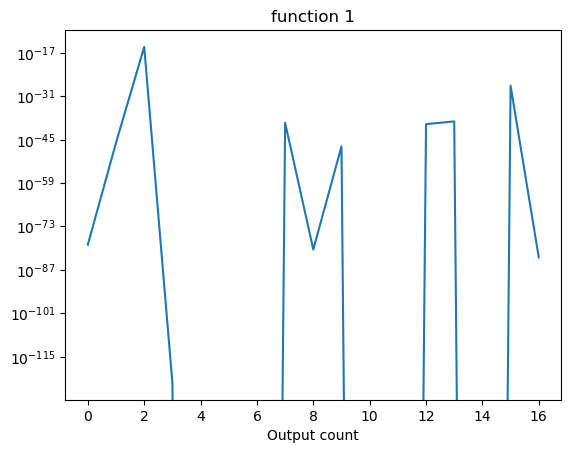

[[3.19403889e-01 7.62959374e-01]
 [5.74329215e-01 8.79898105e-01]
 [7.31023631e-01 7.32999876e-01]
 [8.40353417e-01 2.64731614e-01]
 [6.50114060e-01 6.81526352e-01]
 [4.10437137e-01 1.47554299e-01]
 [3.12691157e-01 7.87227779e-02]
 [6.83418169e-01 8.61057464e-01]
 [8.25072518e-02 4.03487506e-01]
 [8.83889829e-01 5.82253974e-01]
 [4.45000000e-03 9.94344000e-01]
 [9.99235000e-01 2.98000000e-04]
 [7.73956000e-01 4.38878000e-01]
 [6.83880000e-01 8.59533000e-01]
 [8.19804000e-01 7.02559000e-01]
 [7.72433000e-01 7.67114000e-01]
 [8.32963000e-01 3.54394000e-01]]
[ 1.32267704e-079  1.03307824e-046  7.71087511e-016  3.34177101e-124
 -3.60606264e-003 -2.15924904e-054 -2.08909327e-091  2.53500115e-040
  3.60677119e-081  6.22985647e-048  0.00000000e+000  0.00000000e+000
  9.65622297e-041  7.35194636e-040 -2.35730938e-030  2.37071263e-028
  1.03356528e-083]


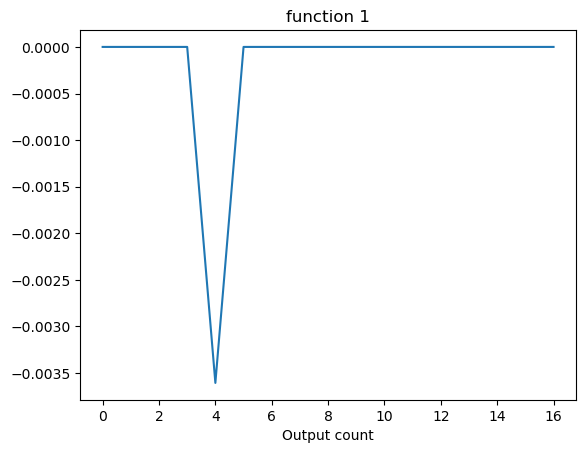

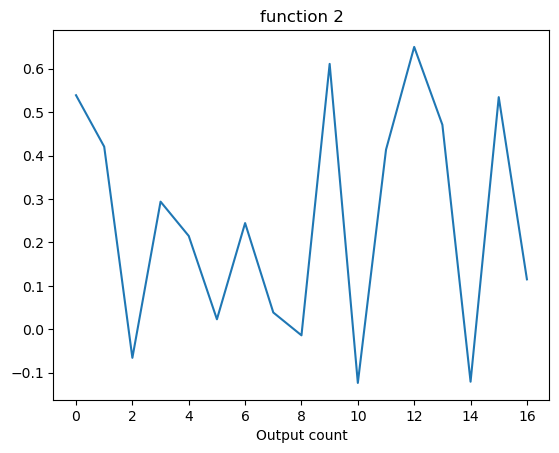

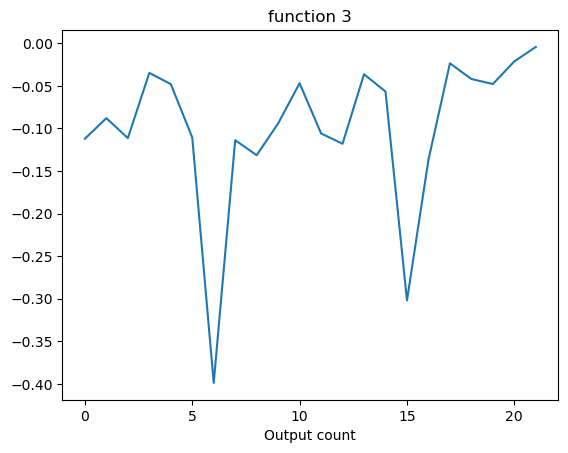

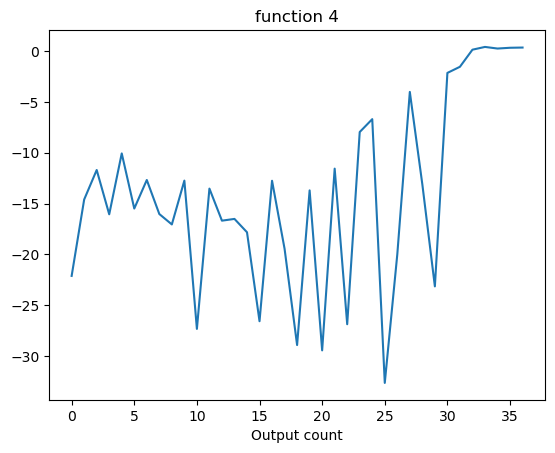

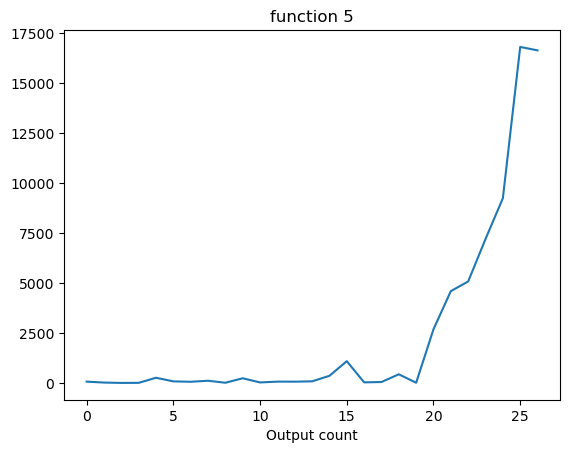

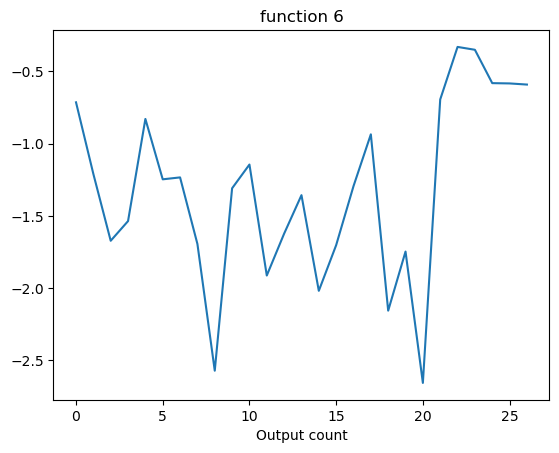

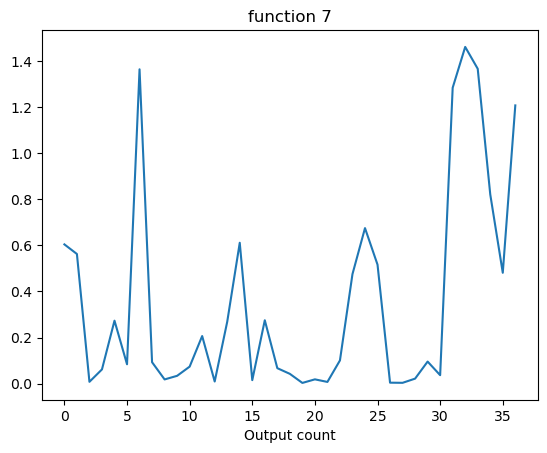

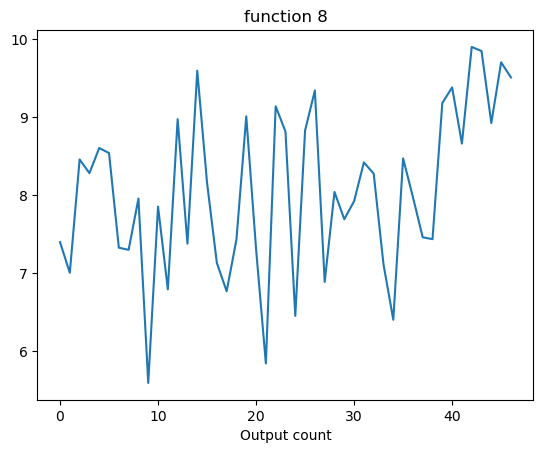

In [13]:
# visualise data so far
for k in range(1,9):
    ins=np.load(f"/Users/luke_dev/Documents/ML_AI_imperial_course_codes/capstone_stage_2/week_8/week_8_data/function_{k}/inputs.npy")
    #print(ins)
    outs=np.load(f"/Users/luke_dev/Documents/ML_AI_imperial_course_codes/capstone_stage_2/week_8/week_8_data/function_{k}/outputs.npy")
    #print(outs_raw.shape)
    

    #ins=scaler.fit_transform(ins_raw, y=outs_raw)

    if k==1:
        plt.plot(outs)
        plt.title(f"function {k}")
        plt.xlabel("Output count")
        plt.yscale('log')

        plt.show()
        print(ins)
        print(outs)


    
    plt.plot(outs)
    plt.title(f"function {k}")
    plt.xlabel("Output count")
    plt.show()



## Current Bayesian optimisation method

In this notebook, I fit a separate Gaussian process (GP) surrogate model to each of the eight black-box objectives using the currently observed input-output pairs. The role of the GP is to provide, for any candidate input \(\mathbf{x}\),

- a **posterior mean** \(\mu(\mathbf{x})\), which estimates the objective value, and
- a **posterior standard deviation** \(\sigma(\mathbf{x})\), which quantifies predictive uncertainty.

This is useful in Bayesian black-box optimisation because the next query should not be chosen only from regions that currently look promising, but also from regions where the surrogate remains uncertain.

In the current version of the notebook, the GP is fitted directly on the **raw input coordinates** and **raw outputs**, while PCA and SVM are used separately as a structure-learning layer for candidate generation.

---

### Observed data and feasible domain

For one black-box function, suppose the observed data are

$$
D_n = \{(\mathbf{x}_i, y_i)\}_{i=1}^n,
$$

where

$$
\mathbf{x}_i \in [0,1]^d,
\qquad
y_i = f(\mathbf{x}_i).
$$

The optimisation problem is therefore

$$
\max_{\mathbf{x} \in [0,1]^d} f(\mathbf{x}),
$$

so all proposed candidate points must satisfy the box constraints

$$
0 \le x_j \le 1,
\qquad j=1,\dots,d.
$$

---

## Gaussian process surrogate model

The latent objective is modelled as a Gaussian process,

$$
f(\mathbf{x}) \sim \mathcal{GP}\!\left(m(\mathbf{x}),\,k(\mathbf{x},\mathbf{x}')\right).
$$

In practice, I use the standard zero-mean GP prior and let the covariance kernel encode the modelling assumptions. The GP is fitted directly to the raw observed inputs and raw outputs.

The kernel in the current implementation has the form

$$
k(\mathbf{x},\mathbf{x}')
=
\sigma_f^2\,k_{\mathrm{base}}(\mathbf{x},\mathbf{x}')
+
\sigma_n^2 \delta_{\mathbf{x},\mathbf{x}'},
$$

where

- \(\sigma_f^2\) is the signal variance,
- \(k_{\mathrm{base}}\) is the main smoothness kernel,
- \(\sigma_n^2\) is the observation noise variance,
- \(\delta_{\mathbf{x},\mathbf{x}'}\) is the Kronecker delta.

For most functions, the base kernel is taken to be a **Matérn kernel**, so in code the GP kernel is of the form

$$
k
=
\text{ConstantKernel}
\times
\text{Matern}
+
\text{WhiteKernel}.
$$

This means that the GP models the objective as a structured latent function plus an independent white-noise term. The Matérn kernel is a natural choice for black-box optimisation because it is less restrictive than the RBF kernel and allows rougher response surfaces.

If the kernel hyperparameters are denoted collectively by

$$
\theta = (\sigma_f^2,\ell,\sigma_n^2),
$$

then \(\ell\) represents the characteristic length scale of variation of the latent function.

---

## Hyperparameter learning via log marginal likelihood

Let

$$
X = \{\mathbf{x}_1,\dots,\mathbf{x}_n\},
\qquad
\mathbf{y} = (y_1,\dots,y_n)^\top.
$$

The covariance matrix over the observed inputs is

$$
K_\theta(X,X)
=
\bigl[k(\mathbf{x}_i,\mathbf{x}_j)\bigr]_{i,j=1}^n.
$$

The GP hyperparameters are not chosen manually. Instead, they are learned from the data by maximising the **log marginal likelihood**

$$
\log p(\mathbf{y}\mid X,\theta)
=
-\frac{1}{2}\mathbf{y}^\top K_\theta^{-1}\mathbf{y}
-\frac{1}{2}\log|K_\theta|
-\frac{n}{2}\log(2\pi).
$$

This objective balances three effects:

- **data fit**, through  
  $$
  -\frac{1}{2}\mathbf{y}^\top K_\theta^{-1}\mathbf{y},
  $$
- **model complexity**, through  
  $$
  -\frac{1}{2}\log|K_\theta|,
  $$
- **Gaussian normalisation**, through  
  $$
  -\frac{n}{2}\log(2\pi).
  $$

In the notebook, this optimisation is performed internally by `GaussianProcessRegressor.fit(...)`, using several optimiser restarts to reduce the risk of converging to a poor local optimum.

---

## GP posterior prediction

After fitting the GP, the posterior distribution at a candidate point \(\mathbf{x}\) is Gaussian, with mean \(\mu(\mathbf{x})\) and variance \(\sigma^2(\mathbf{x})\). For a candidate set \(X_*\), the posterior mean is

$$
\mu(X_*)
=
K(X_*,X)\,K(X,X)^{-1}\mathbf{y},
$$

and the posterior covariance is

$$
\Sigma(X_*)
=
K(X_*,X_*)
-
K(X_*,X)\,K(X,X)^{-1}K(X,X_*).
$$

The uncertainty used in the acquisition functions is the posterior standard deviation

$$
\sigma(\mathbf{x})
=
\sqrt{\operatorname{Var}(f(\mathbf{x})\mid X,\mathbf{y})}.
$$

So each feasible candidate point receives both

- a predicted objective value, and
- an uncertainty estimate.

---

## Acquisition functions

I evaluate three standard Bayesian optimisation acquisition functions on the feasible candidate set.

### Upper Confidence Bound (UCB)

The UCB score is

$$
a_{\mathrm{UCB}}(\mathbf{x})
=
\mu(\mathbf{x}) + \beta\,\sigma(\mathbf{x}),
$$

where \(\beta > 0\) controls the exploration-exploitation trade-off. Larger \(\beta\) gives more weight to uncertain regions.

### Expected Improvement (EI)

Let

$$
f_{\mathrm{best}} = \max_{1 \le i \le n} y_i
$$

be the best observed raw output so far. Define

$$
Z(\mathbf{x})
=
\frac{\mu(\mathbf{x}) - f_{\mathrm{best}} - \xi}{\sigma(\mathbf{x})},
$$

where \(\xi \ge 0\) is an exploration parameter. Then the expected improvement is

$$
a_{\mathrm{EI}}(\mathbf{x})
=
\bigl(\mu(\mathbf{x}) - f_{\mathrm{best}} - \xi\bigr)\Phi(Z(\mathbf{x}))
+
\sigma(\mathbf{x})\phi(Z(\mathbf{x})),
$$

where \(\Phi\) and \(\phi\) are the standard normal CDF and PDF.

### Probability of Improvement (PI)

Using the same \(Z(\mathbf{x})\), the probability of improvement is

$$
a_{\mathrm{PI}}(\mathbf{x})
=
\Phi(Z(\mathbf{x})).
$$

This measures only the probability of beating the current best value by at least \(\xi\), not the expected size of the improvement.

---

## PCA and SVM structure-learning layer

Alongside the GP, I use PCA and an SVM classifier to define a coarse promising region for candidate generation.

### Standardisation for PCA

Although the GP is trained on the raw inputs, the observed inputs are standardised before PCA. If the raw input is

$$
\mathbf{x} = (x_1,\dots,x_d),
$$

then the standardised coordinates are

$$
x_j^{\mathrm{std}}
=
\frac{x_j - \bar{x}_j}{s_j},
\qquad j=1,\dots,d,
$$

where \(\bar{x}_j\) and \(s_j\) are the sample mean and sample standard deviation of the \(j\)-th coordinate across the observed dataset.

This preprocessing is used only for the PCA/SVM stage, not for GP fitting.

### PCA projection

If \(X_{\mathrm{std}}\) denotes the standardised input matrix, PCA projects the data into a two-dimensional representation,

$$
X_{\mathrm{PCA}} = X_{\mathrm{std}}W,
$$

where the columns of \(W\) are the leading principal directions. I retain the first two principal components in order to visualise the current input cloud and to construct a lower-dimensional region proposal mechanism.

### Binary success labels

The observed outputs are sorted, and the top-performing fraction is labelled as a success class. If the cutoff value is denoted by \(y_{\mathrm{cutoff}}\), then the labels are

$$
\ell_i
=
\begin{cases}
1, & y_i \ge y_{\mathrm{cutoff}}, \\[4pt]
0, & y_i < y_{\mathrm{cutoff}}.
\end{cases}
$$

In the current implementation, this defines a binary classification problem in the 2D PCA plane.

### SVM in PCA space

An RBF-kernel support vector machine is then fitted to the PCA-transformed points and their binary labels. The purpose of this step is not to replace the GP, but to identify a coarse **promising region** in reduced coordinates.

Random points are generated in the PCA plane and accepted only if they lie in the positive SVM region. These candidate points are then mapped back to the original coordinate system in two steps:

1. inverse PCA transform back to standardised input space,
2. inverse standardisation back to raw input space.

If \(\mathbf{z}\) is a point in PCA space, then its reconstructed raw-space approximation is

$$
\mathbf{x}_{\mathrm{cand}}
=
T^{-1}_{\mathrm{std}}\!\left(W\mathbf{z}\right),
$$

where \(T^{-1}_{\mathrm{std}}\) denotes the inverse standardisation map.

---

## Feasibility filtering in the unit hypercube

Because the true admissible domain is \([0,1]^d\), not every inverse-mapped PCA candidate is feasible. Therefore, after reconstructing a raw candidate point \(\mathbf{x}_{\mathrm{cand}}\), I impose the feasibility constraint

$$
0 \le x_{\mathrm{cand},j} \le 1,
\qquad j=1,\dots,d.
$$

Only candidates satisfying this box constraint are retained. In matrix form, the feasible candidate set is

$$
\mathcal{C}_{\mathrm{feasible}}
=
\left\{
\mathbf{x} \in \mathcal{C}
:
0 \le x_j \le 1 \text{ for all } j
\right\}.
$$

The GP posterior mean and uncertainty are then evaluated only on this feasible raw candidate set.

---

## Current workflow

For each black-box function, the current method is:

1. Load the current observed input-output pairs.
2. Fit a GP surrogate directly on the raw inputs and raw outputs.
3. Learn the GP kernel hyperparameters by maximising the log marginal likelihood.
4. Standardise the observed inputs and compute a 2D PCA representation.
5. Threshold the observed outputs to define a binary success label.
6. Fit an RBF-kernel SVM in the PCA plane.
7. Randomly sample candidate points in the PCA plane and keep only those classified as promising by the SVM.
8. Map those candidates back to raw input space.
9. Reject any candidate that falls outside the feasible domain \([0,1]^d\).
10. Evaluate the GP posterior mean and standard deviation on the feasible raw candidates.
11. Apply UCB, EI, and PI to select proposed next query points.

---

## Interpretation of the method

The method therefore combines three components:

- a **Gaussian process surrogate** to model the black-box function and quantify uncertainty,
- **standard acquisition functions** to trade off exploration and exploitation,
- a **PCA + SVM candidate-generation layer** to restrict attention to regions that appear promising based on the observed data geometry.

The GP remains the central probabilistic model. The PCA/SVM stage is used only to focus the search over candidate points before the acquisition functions are applied.

(27,)
scaled outs  [-0.5013843  -0.51120985 -0.51508292 -0.5142103  -0.46008922 -0.49840505
 -0.50284761 -0.49177459 -0.51322287 -0.46544403 -0.50990629 -0.50138926
 -0.50159016 -0.49812935 -0.439341   -0.28324379 -0.50896005 -0.50548595
 -0.42319879 -0.51298345  0.05721249  0.46346036  0.56643012  1.019406
  1.45413157  3.06706095  3.03019732]
raw outs [6.44434399e+01 1.83013796e+01 1.12939795e-01 4.21089813e+00
 2.58370525e+02 7.84343889e+01 5.75715369e+01 1.09571876e+02
 8.84799176e+00 2.33223610e+02 2.44230883e+01 6.44201468e+01
 6.34767158e+01 7.97291299e+01 3.55806818e+02 1.08885962e+03
 2.88667516e+01 4.51815703e+01 4.31612757e+02 9.97233189e+00
 2.68768651e+03 4.59547932e+03 5.07903869e+03 7.20627225e+03
 9.24780000e+03 1.68223259e+04 1.66492095e+04]


/opt/anaconda3/envs/ml_env/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


Function 5 analysis
Explained variance: [0.51618598 0.23117378]
Cumulative: [0.51618598 0.74735976]


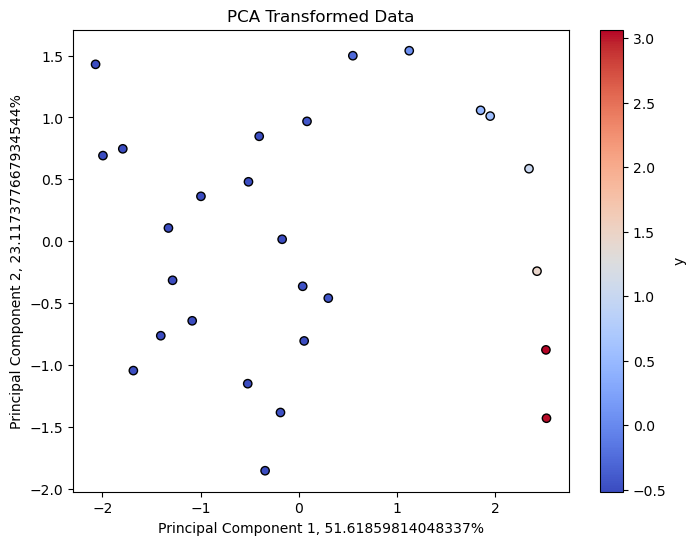

     Outputs
25  3.067061
26  3.030197
24  1.454132
23  1.019406
1.0194060004783452
cutoff for high values 1.0194060004783452
Positive indices: [23 24 25 26]
Positive PCA coordinates:
[[ 2.34532721  0.58597905]
 [ 2.42691725 -0.24228024]
 [ 2.51775824 -0.87857533]
 [ 2.52334819 -1.43110228]]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1]


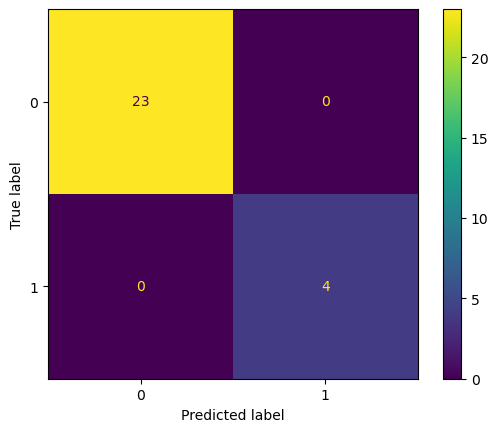

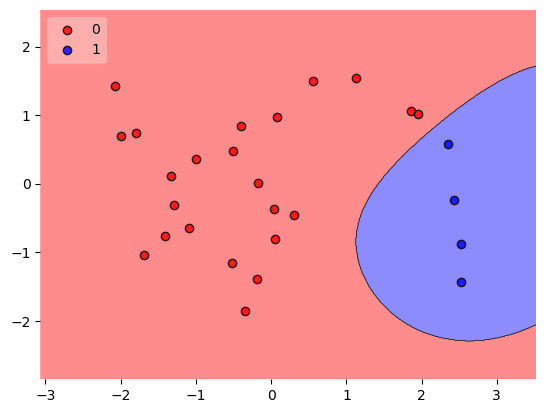

shape of generated input points array (5000, 4)
shape of masked generated input points array (5000, 4)
UCB: 0.868011-0.797736-0.392207-0.999967
EI: 0.870392-0.794714-0.383728-0.998853
PI: 0.870392-0.794714-0.383728-0.998853
previous point tried  [1.1188   0.975906 0.477643 1.302464]
previous output 16649.209506168325, max output 16822.325905059733


In [16]:

sample_size=int(1e6)
for k in range(5,6): #9
    
    ins_raw = np.load(
        f"/Users/luke_dev/Documents/ML_AI_imperial_course_codes/capstone_stage_2/week_8/week_8_data/function_{k}/inputs.npy"
    )
    outs_raw=np.load(
        f"/Users/luke_dev/Documents/ML_AI_imperial_course_codes/capstone_stage_2/week_8/week_8_data/function_{k}/outputs.npy"
    )
    print(outs_raw.shape)

  

    input_scaler = StandardScaler()
    output_scaler = StandardScaler()
   
    ins = input_scaler.fit_transform(ins_raw)
    outs = output_scaler.fit_transform(outs_raw.reshape(-1, 1)).ravel()

    print("scaled outs ", outs)
    print("raw outs", outs_raw)
    
    # train GPR on raw data 
    in_cols=ins.shape[1]
    
    post_mean, post_std, sample_ins, model_GPR= GPR_with_learned_hyperparameters_custom_kernels(
    ins_raw,
    outs_raw,
    sample_size,
    in_cols,
    k,
    initial_length_scale=0.5,
    initial_noise=1e-4,
    n_restarts=10
)
    # insert scaled data into pd dataframes 
    X=pd.DataFrame(ins)
    y = pd.DataFrame({"Outputs": outs})


    print(f"Function {k} analysis")
    X_pca, pca_model  =conduct_PCA_homemade(X,y)

    # sort data and take top 10% as the bound of the cutoff 
    top_prcnt=0.1
    exp_cutoff=sort_data_take_x_percent_top_values(y,top_prcnt)
    
    y_labels = [1 if x >= exp_cutoff else 0 for x in y["Outputs"]]
    print("cutoff for high values",exp_cutoff)

    def apply_SVM_only_sample_success_regions(X_pca,y, exp_cutoff, reg_C):
        # label data based on some inequality calling the bound exp_cutoff

        y_labels=[1 if x>=exp_cutoff else 0 for x in y["Outputs"]]
        print(y_labels)
        # could implement k-fold cross validation to check the model performs well on unseen data , thus validating choice for C, though the data is very snmall
        clf = svm.SVC(kernel='rbf', C=reg_C, gamma='scale')
        clf.fit(X_pca, y_labels)
        cm = confusion_matrix(y_labels, clf.predict(X_pca))
        cmd = ConfusionMatrixDisplay(cm, display_labels=np.unique(y_labels))
        cmd.plot()
        plt.show()

        plot_decision_regions(X_pca, np.array(y_labels).astype('int'), clf=clf, legend=2, colors = "red,blue", markers= "o");
        ax=plt.gca()
        plt.show()

        return clf 

    positive_idx = np.where(np.array(y_labels) == 1)[0]
    print("Positive indices:", positive_idx)
    print("Positive PCA coordinates:")
    print(X_pca[positive_idx])
    y_labels=[1 if x>=exp_cutoff else 0 for x in y["Outputs"]]
    print(y_labels)
    reg_C=100 # regularisation parameter for SVM, larger gives more complex boundaries
    clf=apply_SVM_only_sample_success_regions(X_pca,y, exp_cutoff, reg_C)
    

    sample_size_decision_region=int(5000)
    decision_region_sample_ins=np.zeros(( sample_size_decision_region,2))
    decision_region_sample_ins=generating_decision_region_coordinates_monte_carlo(clf,X_pca,sample_size_decision_region)
    

    # invert coordinates from PCA plane to scaled space 

    decision_bound_inputs=pca_model.inverse_transform(decision_region_sample_ins)

    #invert coordinates from standard scaling mean=0 , sd=1

    decision_bound_inputs= input_scaler.inverse_transform(decision_bound_inputs)

    print("shape of generated input points array", np.shape(decision_bound_inputs))

    mask=np.all(decision_bound_inputs>=0, axis=1)  

    decision_bound_inputs=decision_bound_inputs[mask]

    print("shape of masked generated input points array", np.shape(decision_bound_inputs))


    # use GPR trained on original inputs to predict values 

    post_mean_dec, post_std_dec = model_GPR.predict(decision_bound_inputs, return_std=True)
    

    # applying acquisition functions to new points 

    f_best = np.max(outs_raw)
    Beta = 1 #used to be 5 , switching to 1 to balance exploration and explotation 
    Xi = 0.05

    x_next_UCB = acquisition_UCB(Beta,post_mean_dec, post_std_dec, decision_bound_inputs)


    ei = accquisition_expected_improvement(post_mean_dec, post_std_dec, f_best, xi=Xi)
    x_next_EI = decision_bound_inputs[np.argmax(ei)]

    pi = accquisition_prob_improve(post_mean_dec, post_std_dec, f_best, xi=Xi)
    x_next_PI = decision_bound_inputs[np.argmax(pi)]

    next_points = {
    "UCB": np.round(x_next_UCB, 6),
    "EI": np.round(x_next_EI, 6),
    "PI": np.round(x_next_PI, 6),
    }
    # function
    for name, point in next_points.items():
        formatted = "-".join(f"{x:.6f}" for x in point)
        print(f"{name}: {formatted}")
    print("previous point tried ", ins_raw[-1])
    print(f"previous output {outs_raw[-1]}, max output {np.max(outs_raw)}" )

## Next steps and planned improvements

The current method provides a workable Bayesian optimisation pipeline, but the next stage of development should focus less on adding complexity for its own sake and more on **testing, validation, and controlled comparison**. In particular, I want to understand which parts of the workflow genuinely improve next-point selection and which parts are mainly heuristic.

---

### 1. Surrogate validation

A first priority is to assess how well the Gaussian process behaves as a surrogate model for the black-box objective. In Bayesian optimisation, the GP does not need to be perfect everywhere, but it should provide useful local guidance through both its posterior mean and its uncertainty estimates.

A natural way to test this is through **cross-validation on the observed data**, for example:

- **leave-one-out validation**, where one observed point is removed, the GP is fitted on the remaining points, and the held-out output is predicted;
- **rolling or sequential validation**, where the GP is repeatedly fitted on the first \(m\) observations and asked to predict the next observed point.

These tests would allow me to compare the predicted mean \(\mu(\mathbf{x}_i)\) against the known output \(y_i\), giving metrics such as:

- mean absolute error,
- root mean squared error,
- rank correlation,
- empirical coverage of predictive intervals.

This would not directly measure optimisation performance, but it would help assess whether the GP is learning a sensible local approximation to the objective.

---

### 2. Validation of the full Bayesian optimisation process

Surrogate accuracy alone is not the whole story, because a good optimisation method is not defined only by low prediction error. The real question is whether the pipeline proposes **better next points**.

So a second priority is to test the full method retrospectively using earlier rounds of the optimisation process. For example, if the first \(m\) observations are treated as the available dataset, then the current method can be used to generate a proposed next point, and that proposal can be compared against what was actually observed at the next stage of the sequence.

The most relevant performance quantities here are:

- the **best observed value so far**,
  $$
  y_{\max}^{(m)} = \max_{1 \le i \le m} y_i,
  $$
- the **improvement achieved by the proposed next point**,
  $$
  \Delta^{(m+1)} = y_{m+1} - y_{\max}^{(m)},
  $$
- the frequency with which a method proposes a point that improves on the incumbent best value.

This type of validation is more closely aligned with the real BO objective than standard regression accuracy alone.

---

### 3. Ablation studies

The current pipeline contains several distinct ingredients:

1. the Gaussian process surrogate,
2. the choice of kernel,
3. the acquisition function,
4. the PCA dimensionality-reduction step,
5. the SVM-based promising-region filter,
6. the feasibility filtering in the unit hypercube.

An important next step is therefore to perform **ablation studies**, in which one component is removed or replaced while the rest of the pipeline is held fixed. The aim is to determine which components genuinely contribute to optimisation performance.

The most useful ablations are likely to be:

- **GP-only vs GP + PCA/SVM**, to test whether the structure-learning layer improves candidate selection;
- **Matérn vs RBF kernels**, to test whether rougher or smoother prior assumptions are more appropriate for different black-box tasks;
- **EI vs UCB vs PI**, to compare how different acquisition rules affect the proposed points;
- **ARD vs non-ARD kernels**, especially for higher-dimensional problems where some variables may be more influential than others.

These ablations should be evaluated using optimisation-relevant quantities such as improvement over the current best value, rather than only model-fit statistics.

---

### 4. Stronger testing of the PCA/SVM stage

The PCA/SVM layer is currently a heuristic candidate-generation device. It may help by restricting attention to regions that appear promising, but it may also become too restrictive when the dataset is small.

So this part of the workflow should be tested particularly carefully. Useful questions include:

- Does the SVM region actually contain more high-value candidates than uniform sampling in the feasible domain?
- Does the SVM region become too narrow or unstable as the positive class is defined from only a small number of observations?
- Is the PCA projection preserving enough of the geometry of the promising region?

If the PCA/SVM stage fails these checks, then a simpler GP-only BO baseline may ultimately be preferable.

---

### 5. Possible HEBO-inspired extensions

A further development direction is to borrow selected ideas from the HEBO method. The HEBO paper emphasises two issues that are relevant here: complex noise structure and disagreement between acquisition functions. :contentReference[oaicite:0]{index=0}

Several HEBO-inspired ideas appear especially relevant:

#### (a) Input and output transformations

HEBO uses non-linear transformations to better handle non-stationarity and heteroscedasticity. In particular, it applies power transformations to outputs and warped transformations to inputs before fitting the GP. :contentReference[oaicite:1]{index=1}

For the current project, this suggests possible future experiments with:

- output transforms such as Box-Cox, Yeo-Johnson, or signed-log / `arcsinh`,
- alternative input scalings or warping methods when the function appears strongly non-stationary.

These should be introduced only after the current baseline is validated, so that their effect can be assessed cleanly.

#### (b) More flexible surrogate kernels

HEBO uses an additive kernel combining a linear component and a Matérn component. :contentReference[oaicite:2]{index=2} This suggests a possible extension beyond the current single-kernel setup:

$$
k(\mathbf{x},\mathbf{x}')
=
k_{\mathrm{linear}}(\mathbf{x},\mathbf{x}')
+
k_{\mathrm{Mat\acute{e}rn}}(\mathbf{x},\mathbf{x}').
$$

Such a kernel could capture both broad global trends and local nonlinear variation. This may be useful for functions whose contextual descriptions suggest an overall trend with superimposed local structure.

#### (c) Multi-acquisition ideas

HEBO also addresses disagreement between acquisition functions by treating EI, PI, and UCB as a multi-objective ensemble rather than relying on a single acquisition. :contentReference[oaicite:3]{index=3}

I do not yet plan to adopt the full HEBO machinery immediately, but this motivates a more careful comparison of acquisition rules and may later support a Pareto-style or multi-objective acquisition analysis if the simpler single-acquisition baselines prove insufficient.

---

### 6. A staged development plan

To keep the workflow rigorous, the next developments should be introduced in stages:

1. **Validate the current GP surrogate** using cross-validation and sequential prediction checks.
2. **Compare the full method against simpler baselines**, especially GP-only BO without the PCA/SVM stage.
3. **Run ablation studies** on kernel choice, acquisition choice, and candidate filtering.
4. **Only then** introduce more advanced ideas such as transformed outputs, warped inputs, additive kernels, or HEBO-inspired acquisition ensembles.

This ordering is important, because otherwise it becomes difficult to tell which modification is responsible for any observed improvement.

---

### 7. Overall goal

The overall aim of these next steps is not simply to make the method more elaborate, but to make it more **trustworthy, interpretable, and testable**. A strong optimisation pipeline should not only produce plausible next points, but also provide evidence that its components are contributing meaningfully to the search process.
-




%%Ablation study of the PCA/SVM search.